In [31]:
import autoslo.utils.paths as pu
import os

from autoslo.workload_execution.trace import Trace
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from autoslo.utils.colors import Palette

In [22]:
run_seqnum = pu.RunLocator.get_run_ids(query_router_name='SeqNum')
run_modelbased = pu.RunLocator.get_run_ids(query_router_name='ModelBased')
run_seqnum, run_modelbased

(['1768517631'], ['1768544717'])

In [23]:
trace_seqnum = Trace(run_seqnum[0])
trace_modelbased = Trace(run_modelbased[0])

In [24]:
def transform_trace(tr: Trace, suffix: str) -> pd.DataFrame:
    return (
        tr.seq_nums.to_frame(name="seq_num")
        .join(
            tr.latencies_s.to_frame(name=f"latency_s_{suffix}"),
            how="inner",
        )
        .join(
            tr.routing_decisions.to_frame(name=f"routed_cluster_{suffix}"),
            how="inner",
        )
        .set_index("seq_num")
        .sort_index()
    )

transformed_1 = transform_trace(trace_seqnum, "seqnum")
transformed_2 = transform_trace(trace_modelbased, "modelbased")

df_combined = transformed_1.join(
    transformed_2, how="inner"
)

In [25]:
df_combined

,latency_s_seqnum,routed_cluster_seqnum,latency_s_modelbased,routed_cluster_modelbased
seq_num,,,,
0,0.660081,cluster_8,14.194377,cluster_8
1,3.043857,cluster_8,16.131165,cluster_8
2,2.768923,cluster_8,12.924958,cluster_8
3,20.026730,cluster_8,370.599504,cluster_8
4,31.519967,cluster_16,46.235048,cluster_16
...,...,...,...,...
114,22.023841,cluster_8,8.246135,cluster_8
115,21.532354,cluster_8,9.326208,cluster_8
116,36.587656,cluster_8,36.722991,cluster_8


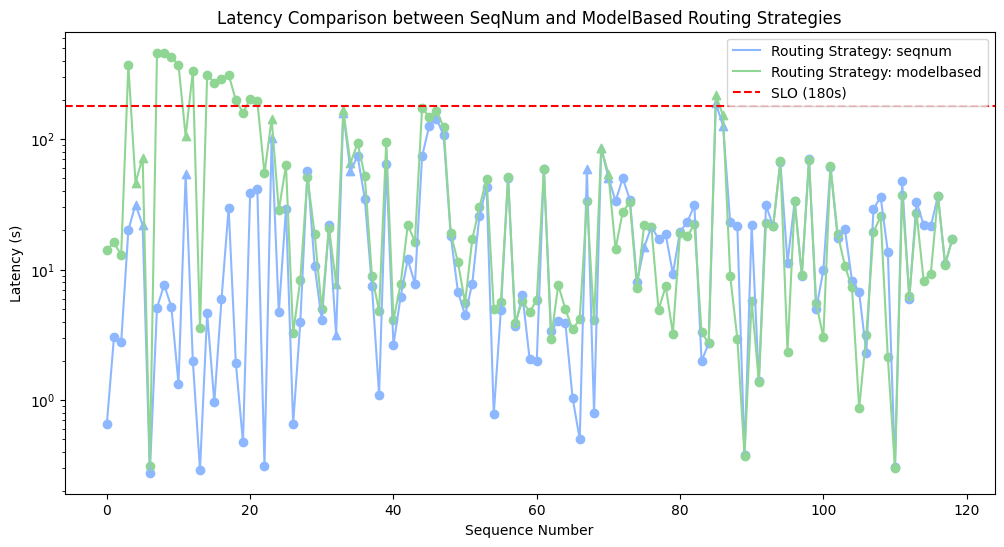

In [39]:
# Plot the latency on the y axis in a log scale, the seq num on the x axis, 
# and then have a separate line for each routing strategy. Make the  shape of
# the points indicate the routed cluster. There should only be on eline per strategy,
# and it should pass through all of its points, regardless of cluster.

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'seqnum': Palette.light_blue, 'modelbased': Palette.light_green}

for strategy in ['seqnum', 'modelbased']:
    ax.plot(
        df_combined.index,
        df_combined[f'latency_s_{strategy}'],
        linestyle='-',
        label=f'Routing Strategy: {strategy}',
        color=colors[strategy]
    )

    for cluster in df_combined[f'routed_cluster_{strategy}'].unique():
        cluster_points = df_combined[df_combined[f'routed_cluster_{strategy}'] == cluster]
        ax.scatter(
            cluster_points.index,
            cluster_points[f'latency_s_{strategy}'],
            color =colors[strategy],
            marker = 'o' if ('8' in str(cluster)) else '^'
        )

# Add a horizontal line at the SLO of 180s
ax.axhline(y=180, color='r', linestyle='--', label='SLO (180s)')

    
ax.set_yscale('log')
ax.set_xlabel('Sequence Number')
ax.set_ylabel('Latency (s)')
ax.set_title('Latency Comparison between SeqNum and ModelBased Routing Strategies')
ax.legend()

Text(0.5, 1.0, 'Latency Ratio between ModelBased and SeqNum Routing Strategies')

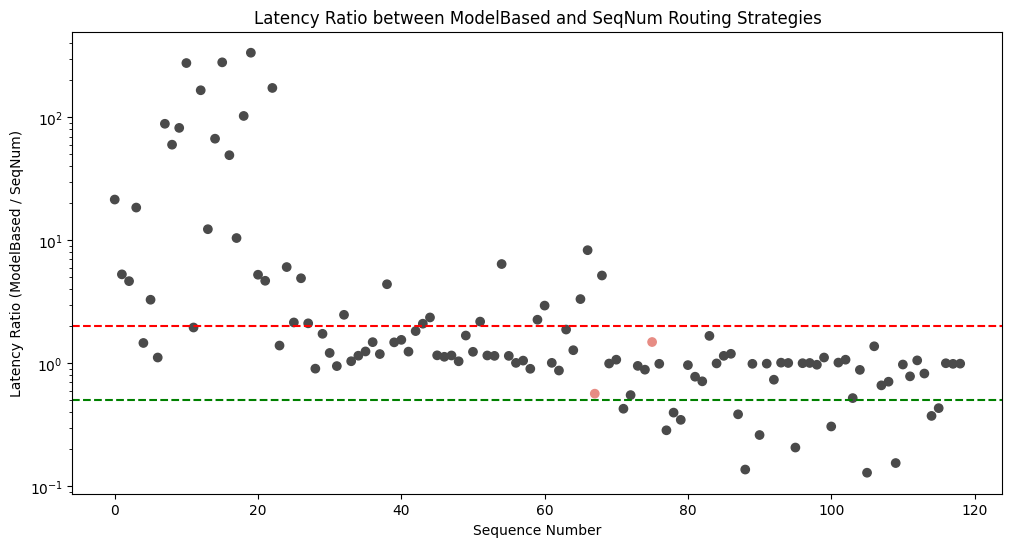

In [40]:
# For each sequence number, plot the ratio in latency between the two strategies.
# Color the point red if the strategies routed to different clusters, otherwise gray.

fig, ax = plt.subplots(figsize=(12, 6))
latency_ratio = df_combined['latency_s_modelbased'] / df_combined['latency_s_seqnum']
matches = df_combined['routed_cluster_seqnum'] == df_combined['routed_cluster_modelbased']

ax.scatter(
    df_combined.index,
    latency_ratio,
    c=[Palette.gray if match else Palette.light_red for match in matches],
)

# Plot horizontal lines at 2 and 0.5
ax.axhline(y=2, color='r', linestyle='--', label='Latency Ratio = 2')
ax.axhline(y=0.5, color='g', linestyle='--', label='Latency Ratio = 0.5')

ax.set_xlabel('Sequence Number')
ax.set_yscale('log')
ax.set_ylabel('Latency Ratio (ModelBased / SeqNum)')
ax.set_title('Latency Ratio between ModelBased and SeqNum Routing Strategies')